## 2D Orzag-Tang vortex evolution

In this example we simulate a modified Orzag-Tang vortex (given in *Loureiro et al. 2016, Comput. Phys. Commun. 206 (2016): 45-63*):
$\Phi = \cos(x+1.4) + \cos(y + 0.5), \quad \Psi = \cos(2x+2.3)+\cos(x+4.1)$

In [2]:
import jax_rmhd as jr
from typing import NamedTuple, Tuple
import jax
from jax import jit
import jax.numpy as jnp
import jax.numpy.fft as ft
from functools import partial
import matplotlib.pyplot as plt
import orbax.checkpoint as ocp
import os
import jax_rmhd.snapshot_io as sn
import jax_rmhd.physics as phys #need this if you want to test out the physics steps
import jax_rmhd.diagnostics as diag

rmhd-solver has initialized jax in 32bit precision.


In [30]:
#parameters
n = 256
Lx = Ly = 2.0*jnp.pi
dx = Lx/n
nupar = 1e-4
dt = 0.01
t = 0.0
nblock = 50
nsnap = 100
t_snap=0.1
t_end=10.0
cfl_safety=1.0 #this is pretty aggressive
snap_path="data/orzag-tang-2D/"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

x = jnp.linspace(0, Lx, n, endpoint=False)
y = jnp.linspace(0, Ly, n, endpoint=False)
x_grid = x.reshape(-1,1)
y_grid = y.reshape(1,-1)

#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
phi = jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)
psi = jnp.cos(2.0*x_grid+2.3) + jnp.cos(y_grid + 4.1)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(n=n,Lx=Lx,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))

In [31]:
#do the simulation
jr.simulate(state,kgrid,params,nblock=nblock,t_snap=t_snap,t_end=t_end,mngr=mngr)

Saving initial state as snapshot 0
---COMPILING block_of_steps---
---COMPILING rk_advance---
0.49983656
Saving snapshot 1
---COMPILING block_of_steps---
---COMPILING rk_advance---
0.9203458
Saving snapshot 2
1.2432083
Saving snapshot 3
1.5447984
Saving snapshot 4
1.8651721
Saving snapshot 5
2.1703606
Saving snapshot 6
2.4734335
Saving snapshot 7
2.7719183
Saving snapshot 8
3.078036
Saving snapshot 9
3.377977
Saving snapshot 10
3.6954453
Saving snapshot 11
4.010029
Saving snapshot 12
4.3356533
Saving snapshot 13
4.656227
Saving snapshot 14
5.000071
Saving snapshot 15
5.3794007
Saving snapshot 16
5.769566
Saving snapshot 17
6.1518703
Saving snapshot 18
6.512838
Saving snapshot 19
6.873353
Saving snapshot 20
7.198646
Saving snapshot 21
7.5118237
Saving snapshot 22
7.9088902
Saving snapshot 23
8.320047
Saving snapshot 24
8.704164
Saving snapshot 25
9.122511
Saving snapshot 26
9.531934
Saving snapshot 27
9.9182205
Saving snapshot 28
10.330851
Saving snapshot 29
Saving final state as snapsho

'Ending simulation at t = 10.330851'

In [50]:
#Making some snapshots.
for isnap in range(0,30):
    snap=sn.load_snapshot(isnap,mngr,params)
    #vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
    #vsq=jnp.sum(jnp.array(jax.tree_util.tree_map(lambda gfk: ft.irfft2(gfk),gradk(snap.fields.phik,kgrid)))**2.0,axis=0)
    vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
    plt.imshow(vort,vmin=-50,vmax=50,cmap="afmhot")
    plt.colorbar()
    plt.savefig(snap_path+str(isnap).zfill(3)+".png")
    plt.close('all')

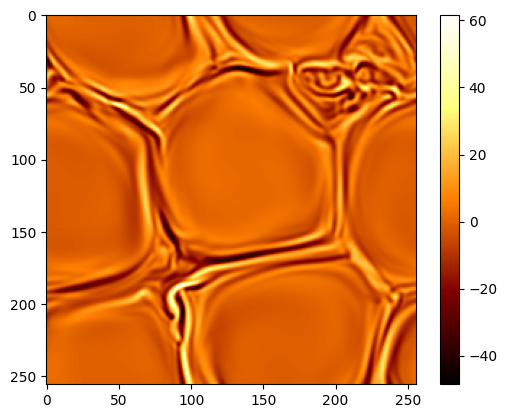

In [48]:
#Plot one of them here
isnap=8
snap=sn.load_snapshot(isnap,mngr,params)
vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
plt.imshow(vort,cmap="afmhot")
plt.colorbar()

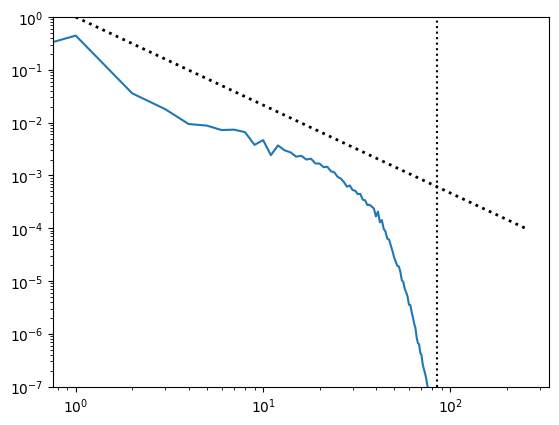

In [34]:
#plot the energy spectrum
isnap=8
snap=sn.load_snapshot(isnap,mngr,params)
k=jnp.array(range(params.n))
su,sb=diag.spec(snap,kgrid,params)
plt.loglog(k,sb)
plt.ylim(1e-7,1)
plt.loglog(k,k**(-5.0/3.0),'k:',linewidth=2)
plt.loglog([params.n//3,params.n//3],[1e-7,1],'k:')

In [51]:
#This makes a gif of the snapshot images if you have imagemagick installed
os.system("cd " + snap_path + ";"
          + "magick -delay 10 -loop 0 *.png orzag-tang-2D.gif;"
         + "cd ../../")

0

Things to mess with if you want to:
- Experiment with different dissipation parameters `visc`,`res`,`hyper`
- Check how the energy in the box evolves (There is a function `energy` in `jax_rmhd.diagnostics.py`)